In [1]:
import pickle
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

## Load GRN, ground-truth fold changes, and simulated data

In [2]:
with open('./DATA/grn.pkl', 'rb') as f:
    grn = pickle.load(f)
with open('./DATA/gt_FCs.pkl', 'rb') as f:
    gt_FCs = pickle.load(f)

adata = sc.read_h5ad('./DATA/perturbseq_all_KOs.h5ad')
print(f"GRN: {grn.n_genes} genes x {grn.n_programs} programs")
print(f"GT FCs: {gt_FCs.shape} (KOs x genes)")
print(f"Simulated adata: {adata.shape}")

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GRN: 5000 genes x 10 programs
GT FCs: (860, 5000) (KOs x genes)
Simulated adata: (51000, 5000)


## Drop filler genes (`GENE_XXXX`) from all three plots

In [3]:
non_filler_mask = np.array([not g.startswith('GENE_') for g in grn.all_genes])
non_filler_genes = [g for g, nf in zip(grn.all_genes, non_filler_mask) if nf]
print(f"Kept {len(non_filler_genes)} non-filler genes out of {len(grn.all_genes)}")

Kept 860 non-filler genes out of 5000


## GRN program membership (rows = programs, columns = genes)

In [4]:
# Binary: 1 if gene has a non-zero W entry for this program
w_non_filler = grn.W[non_filler_mask, :]           # (n_non_filler, n_programs)
membership = (w_non_filler != 0).astype(int).T    # (n_programs, n_non_filler)
membership_df = pd.DataFrame(
    membership, index=grn.program_names, columns=non_filler_genes
)
print(f"Membership matrix: {membership_df.shape}  (programs x non-filler genes)")
print(f"Genes per program:")
print(membership_df.sum(axis=1))

Membership matrix: (10, 860)  (programs x non-filler genes)
Genes per program:
cell_cycle              58
apoptosis              139
immune_response        130
dna_repair              93
metabolism              48
ribosome_biogenesis    144
oxidative_stress        42
autophagy              129
cell_adhesion           65
angiogenesis            47
dtype: int64


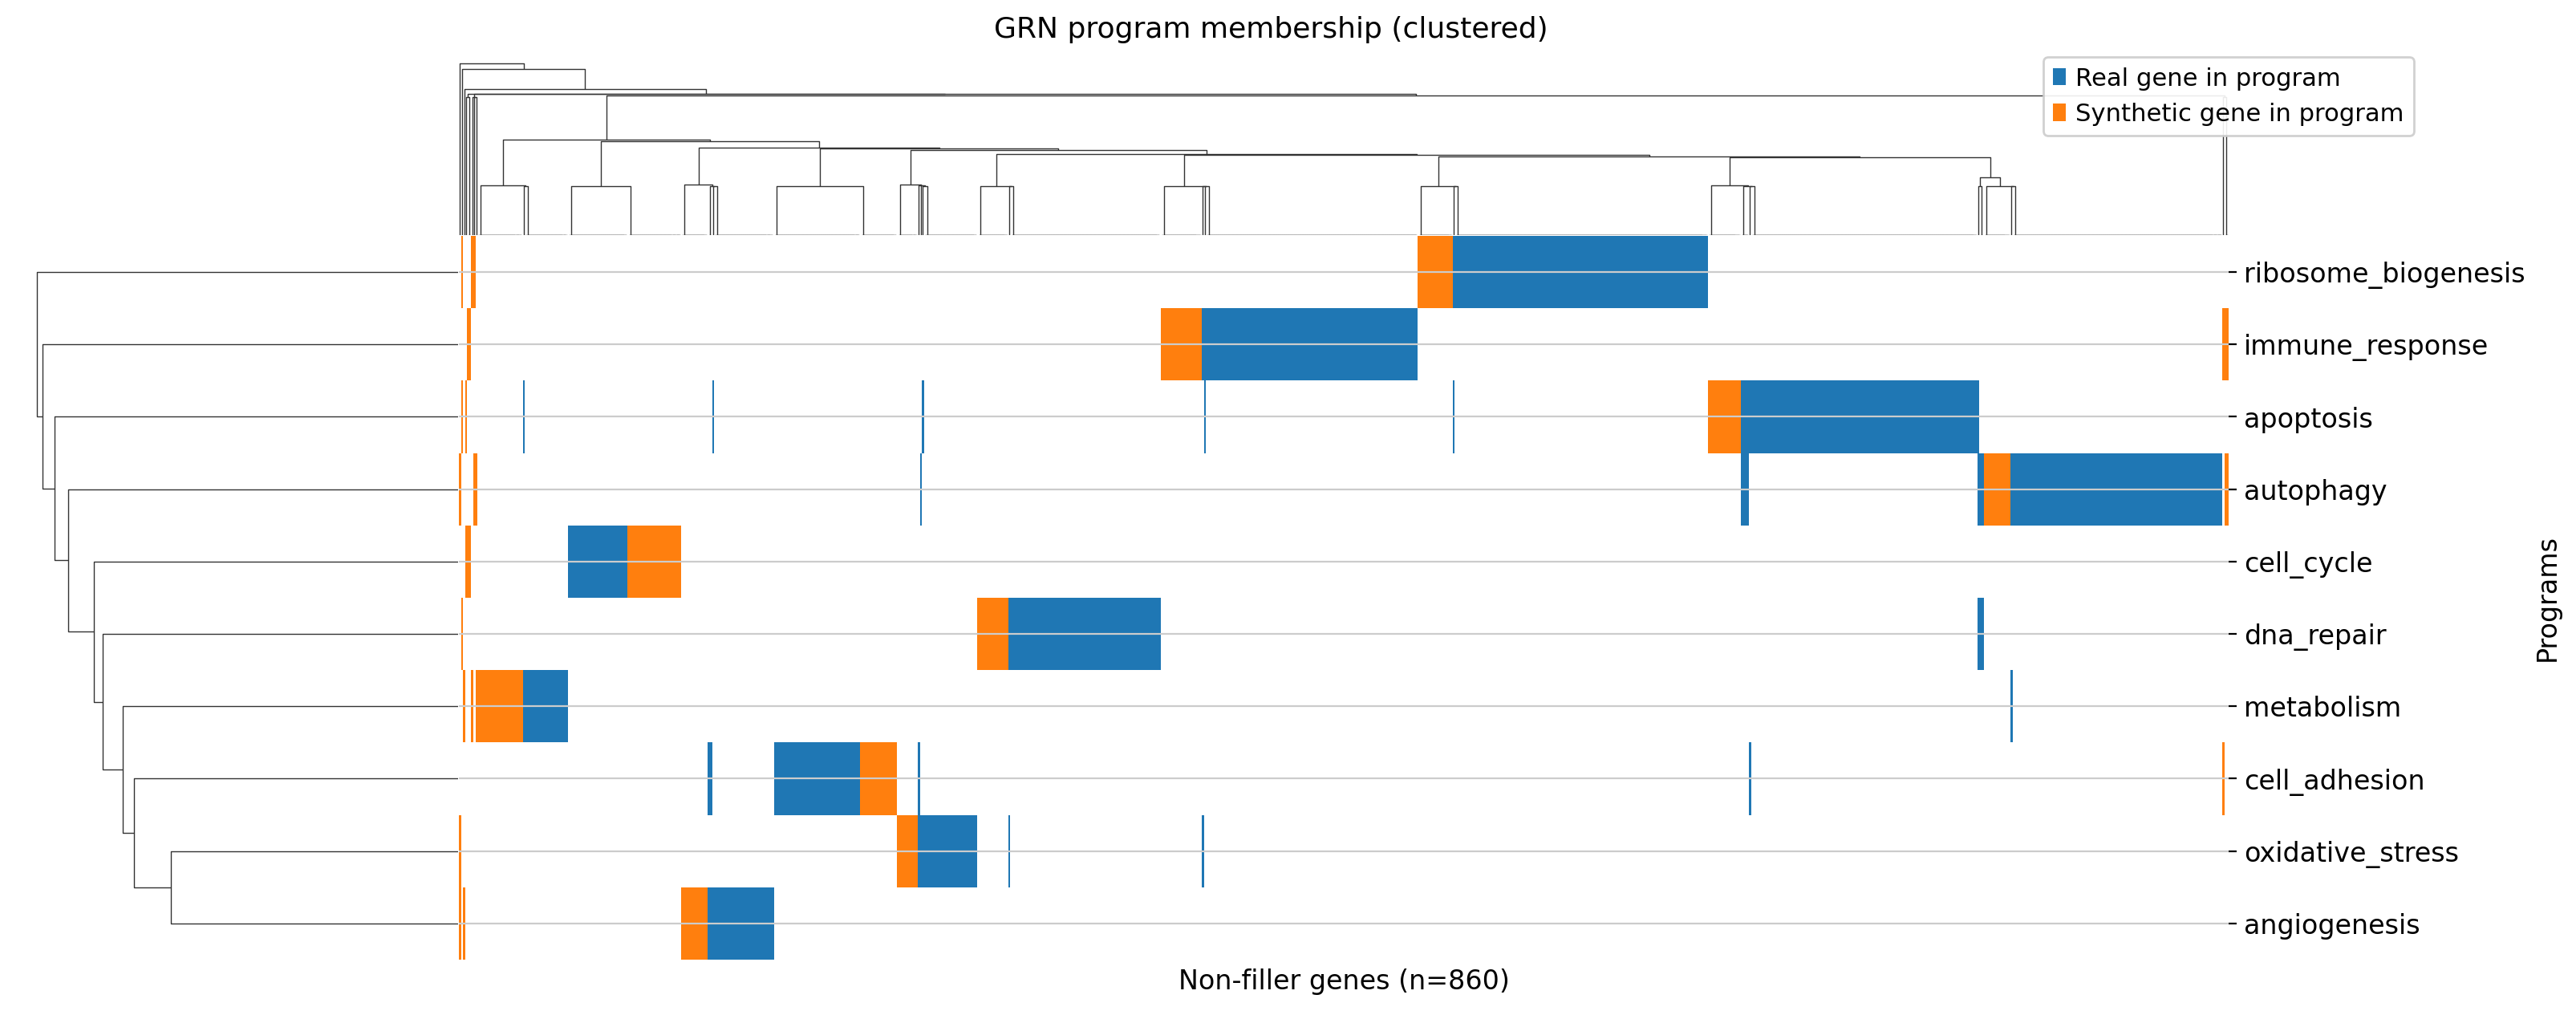

In [5]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Encode gene type into the value matrix:
#   0 = not in program, 1 = real GO gene in program, 2 = synthetic gene in program
synth_mask = np.array([g.startswith('SYN_') for g in membership_df.columns])
value_matrix = membership_df.values.astype(int).copy()
value_matrix[:, synth_mask] = np.where(value_matrix[:, synth_mask] == 1, 2, 0)
value_df = pd.DataFrame(
    value_matrix, index=membership_df.index, columns=membership_df.columns
)

cmap = ListedColormap(['white', '#1f77b4', '#ff7f0e'])   # 0 / 1 / 2

g = sns.clustermap(
    value_df,
    cmap=cmap, vmin=0, vmax=2,
    cbar_pos=None,
    xticklabels=False, yticklabels=True,
    linewidths=0,
    figsize=(16, 6),
    method='average',
)
g.ax_heatmap.set_xlabel(f'Non-filler genes (n={membership_df.shape[1]})')
g.ax_heatmap.set_ylabel('Programs')
g.fig.suptitle('GRN program membership (clustered)', fontsize=13, y=1.01)

legend_elements = [
    Patch(facecolor='#1f77b4', label='Real gene in program'),
    Patch(facecolor='#ff7f0e', label='Synthetic gene in program'),
]
g.fig.legend(handles=legend_elements, loc='upper right',
             bbox_to_anchor=(0.95, 0.98), framealpha=0.9)

# Persist the clustered gene order so the logFC heatmaps below can reuse it
clustered_gene_order = list(g.data2d.columns)

plt.show()

## Log2 fold changes: ground truth vs. empirical estimate (log1p mean-difference)

In [6]:
# Restrict ground truth to non-filler columns; -inf self-perturbation -> NaN for plotting
gt_mat = gt_FCs[[g for g in gt_FCs.columns if g in non_filler_genes]].copy()
gt_mat = gt_mat.replace(-np.inf, np.nan)
print(f"GT logFC (non-filler): {gt_mat.shape}")

GT logFC (non-filler): (860, 860)


In [7]:
# Empirical logFC via mean(log2(X+1)) difference — matches the simulator's log1p-shift GT in expectation
raw = adata.layers['raw_counts'] if 'raw_counts' in adata.layers else adata.X
if sp.issparse(raw):
    raw = raw.toarray()
raw = np.asarray(raw, dtype=np.float64)

groups = adata.obs['perturbation'].values
ctrl_mask = groups == 'control'
log2_ctrl_mean = np.log2(raw[ctrl_mask] + 1).mean(axis=0)

perts = [p for p in np.unique(groups) if p != 'control']
est_rows = {p: np.log2(raw[groups == p] + 1).mean(axis=0) - log2_ctrl_mean
            for p in perts}

est_FCs = pd.DataFrame(est_rows, index=adata.var_names).T
est_mat = est_FCs[[g for g in est_FCs.columns if g in non_filler_genes]]
print(f"Estimated logFC (non-filler): {est_mat.shape}")

Estimated logFC (non-filler): (100, 860)


Shared: 100 perturbations x 860 genes; color scale +/-5.01


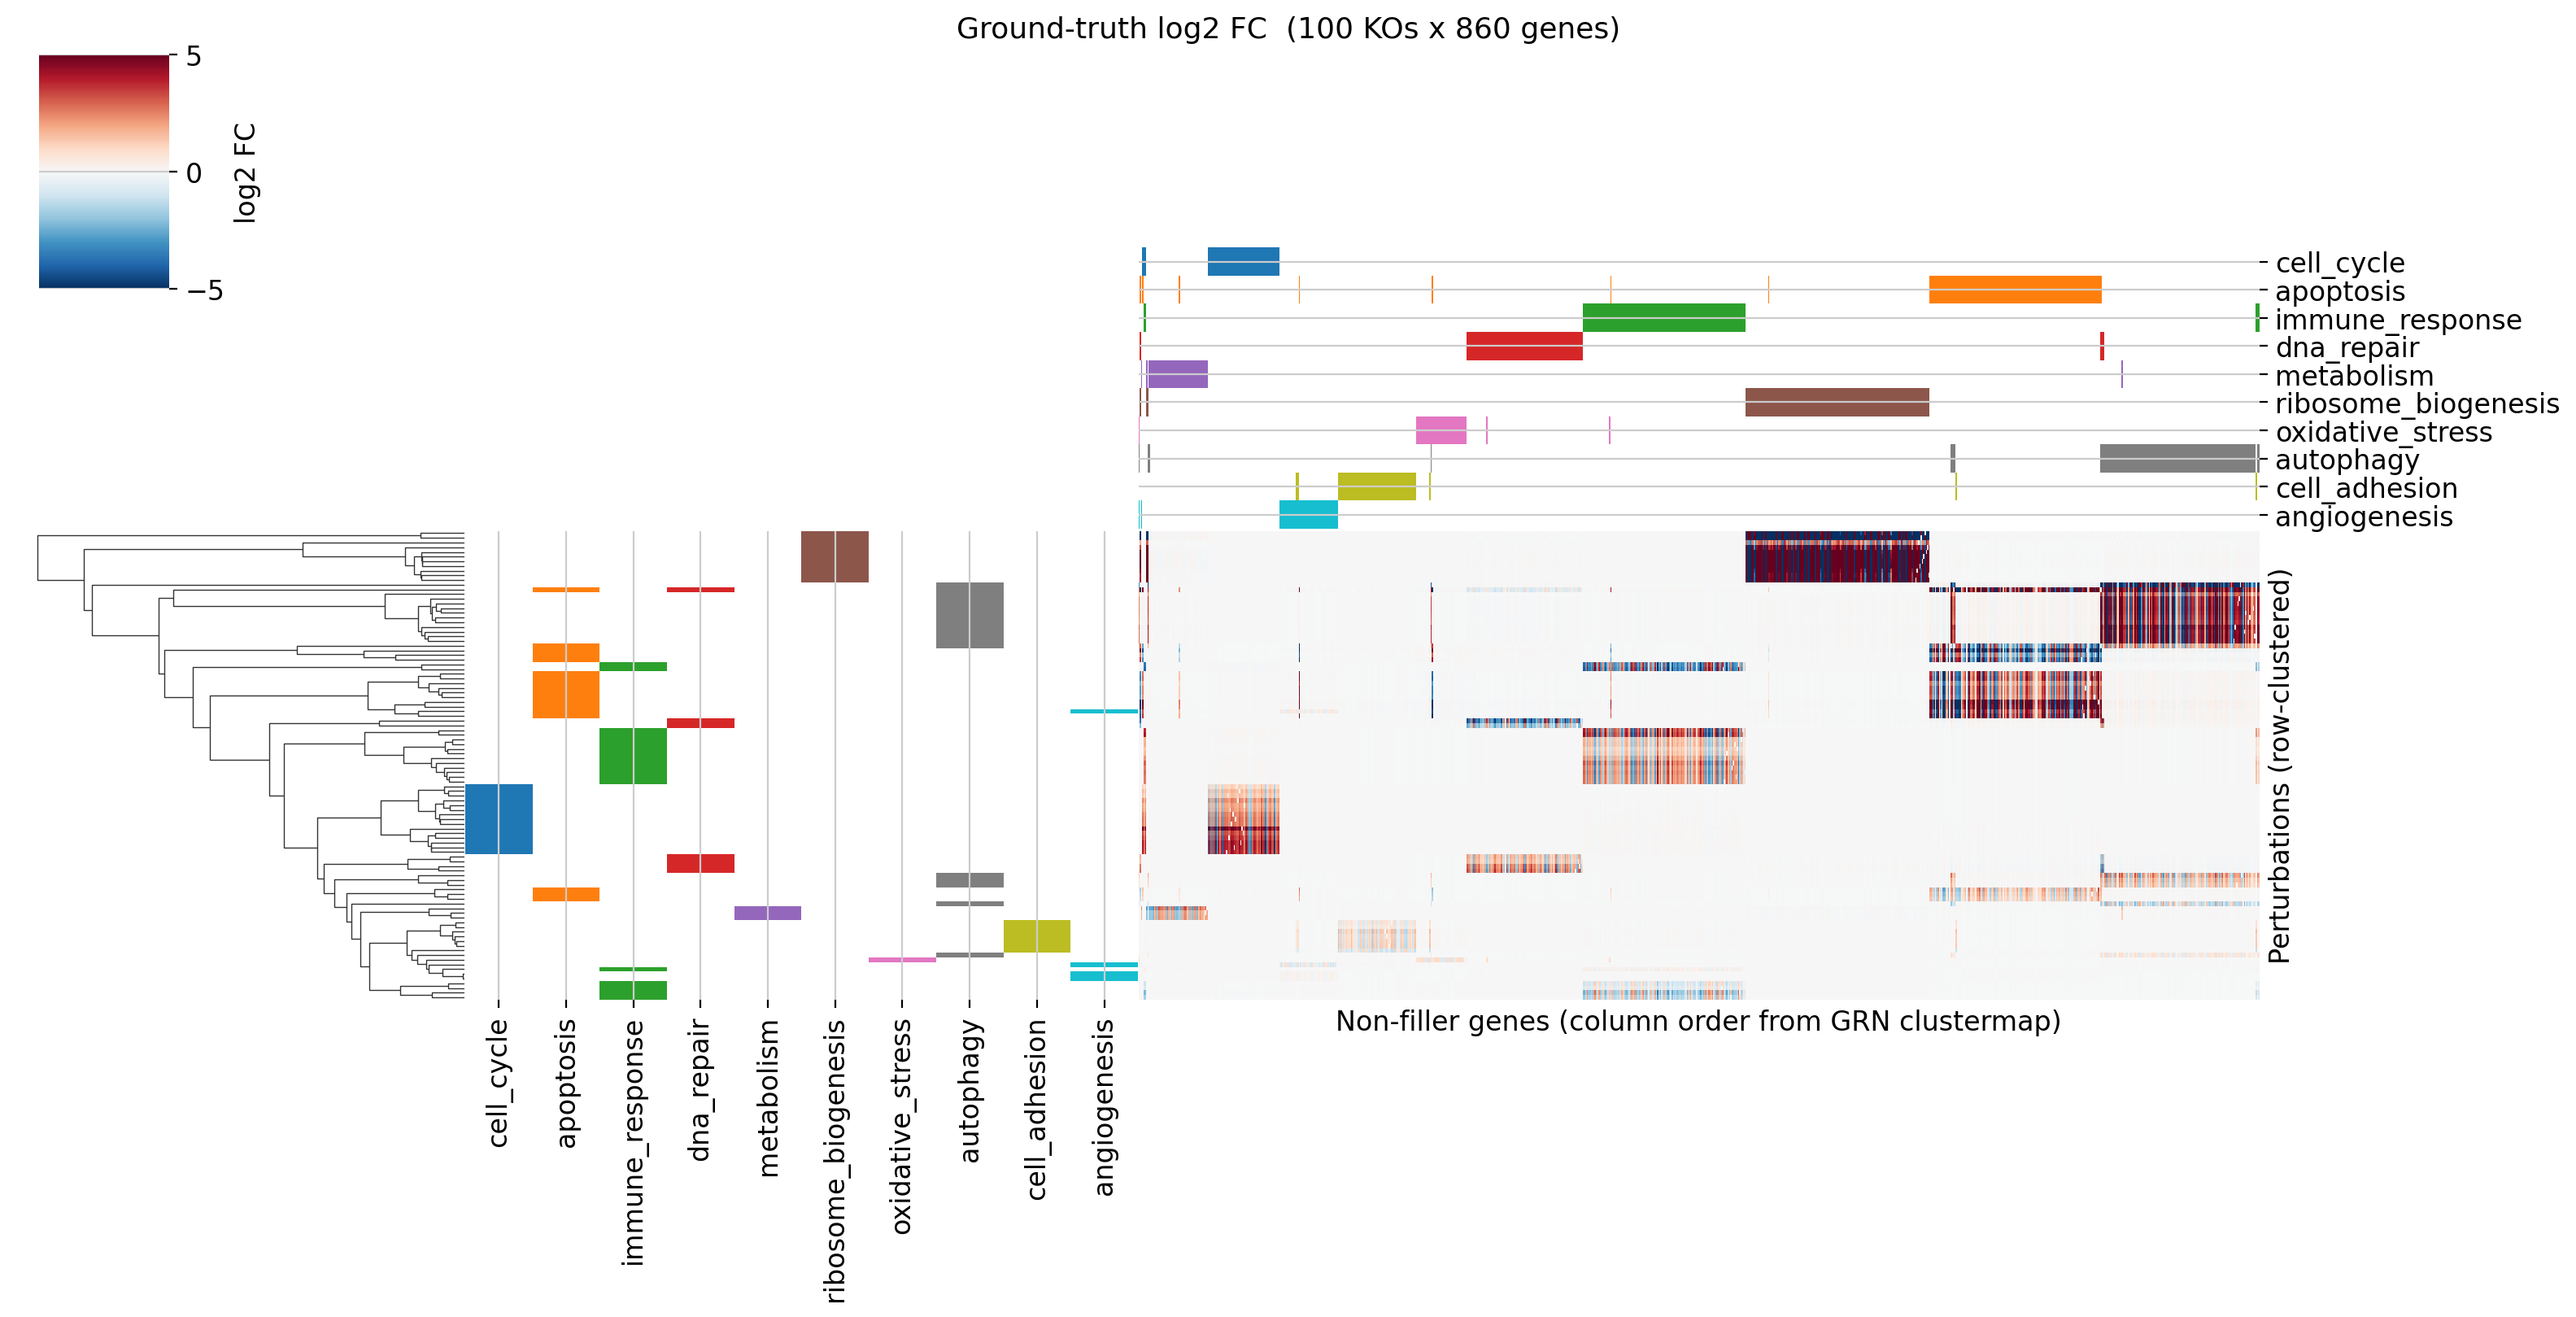

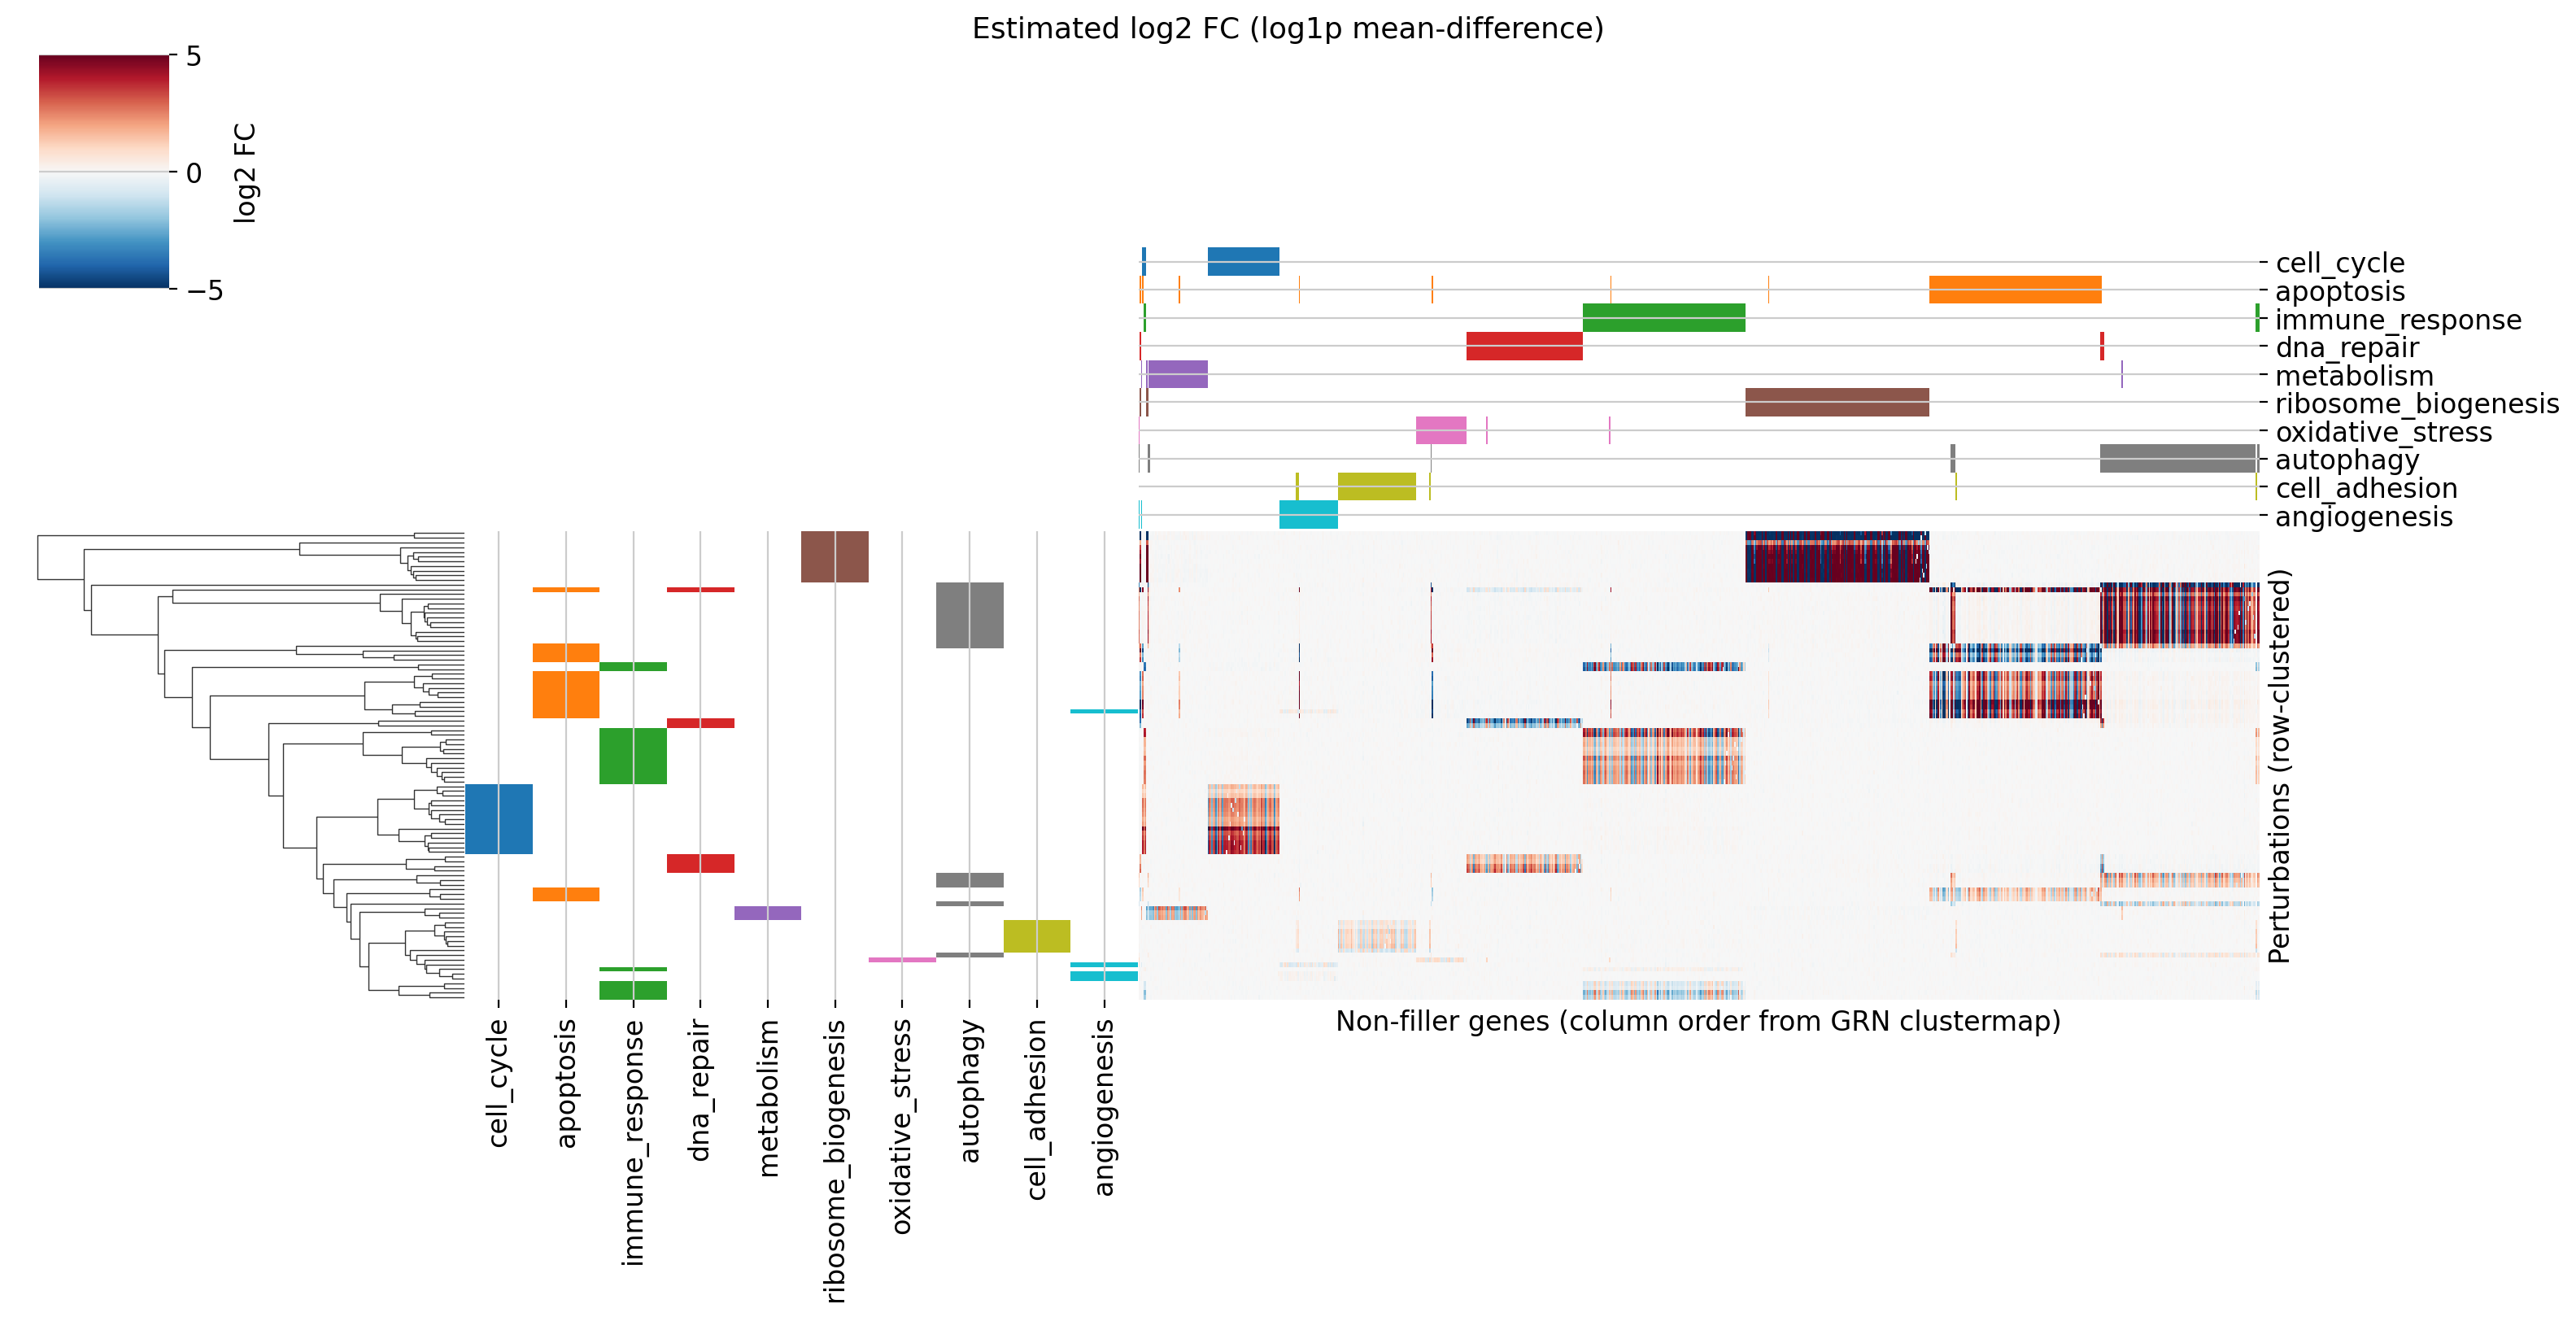

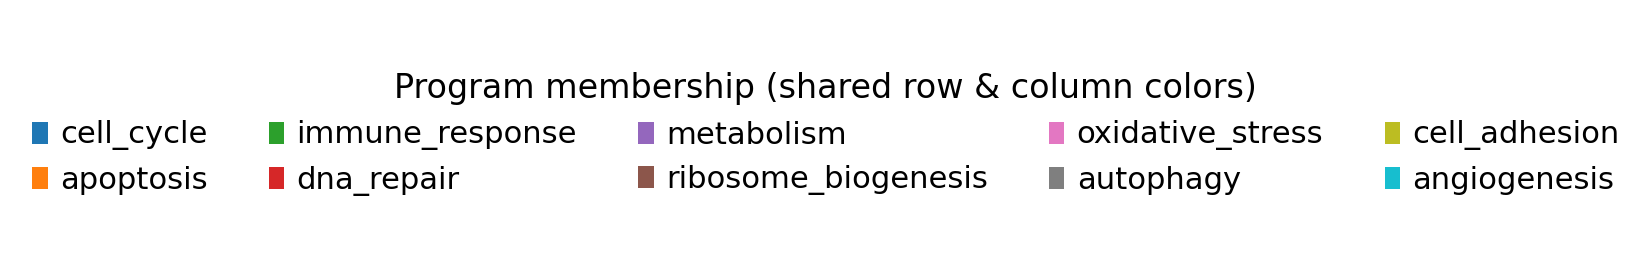

In [8]:
# Align rows and columns (gt has all perturbable KOs, est has only simulated ones)
common_perts = gt_mat.index.intersection(est_mat.index)
common_genes = gt_mat.columns.intersection(est_mat.columns)

# Reuse clustered column order from the GRN heatmap so all three panels share it
common_set = set(common_genes)
ordered_genes = [g for g in clustered_gene_order if g in common_set]

gt_aligned = gt_mat.loc[common_perts, ordered_genes]
est_aligned = est_mat.loc[common_perts, ordered_genes]

# Fill -inf / NaN on the self-KO diagonal so hierarchical clustering doesn't choke
gt_for_plot = gt_aligned.fillna(0)
est_for_plot = est_aligned.fillna(0)

# --- Same color code for row and column annotations ---
program_colors = dict(zip(
    membership_df.index,
    sns.color_palette('tab10', len(membership_df.index))
))

def build_program_colors(gene_list):
    """DataFrame indexed by gene_list, one column per program, colored where gene is a member."""
    df = pd.DataFrame(index=list(gene_list))
    for prog in membership_df.index:
        df[prog] = [
            program_colors[prog]
            if (g in membership_df.columns and membership_df.loc[prog, g] == 1)
            else 'white'
            for g in df.index
        ]
    return df

row_colors = build_program_colors(gt_aligned.index)    # perturbed genes (rows)
col_colors = build_program_colors(ordered_genes)       # target genes    (columns)

# Shared color scale
finite_vals = np.concatenate([
    gt_aligned.values[np.isfinite(gt_aligned.values)],
    est_aligned.values[np.isfinite(est_aligned.values)],
])
vmax = np.percentile(np.abs(finite_vals), 99.5)
print(f"Shared: {len(common_perts)} perturbations x {len(ordered_genes)} genes; color scale +/-{vmax:.2f}")

yticklabels = (len(common_perts) <= 60)

# ---------------- Ground-truth clustermap ----------------
g_gt = sns.clustermap(
    gt_for_plot,
    cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
    row_cluster=True, col_cluster=False,
    xticklabels=False, yticklabels=yticklabels,
    row_colors=row_colors, col_colors=col_colors,
    figsize=(16, 8),
    method='average',
    cbar_kws={'label': 'log2 FC'},
)
g_gt.ax_heatmap.set_xlabel('Non-filler genes (column order from GRN clustermap)')
g_gt.ax_heatmap.set_ylabel('Perturbations (row-clustered)')
g_gt.fig.suptitle(
    f'Ground-truth log2 FC  ({len(common_perts)} KOs x {len(ordered_genes)} genes)',
    fontsize=13, y=1.01,
)
plt.show()

# ---------------- Estimated clustermap ----------------
g_est = sns.clustermap(
    est_for_plot,
    cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
    row_cluster=True, col_cluster=False,
    xticklabels=False, yticklabels=yticklabels,
    row_colors=row_colors, col_colors=col_colors,
    figsize=(16, 8),
    method='average',
    cbar_kws={'label': 'log2 FC'},
)
g_est.ax_heatmap.set_xlabel('Non-filler genes (column order from GRN clustermap)')
g_est.ax_heatmap.set_ylabel('Perturbations (row-clustered)')
g_est.fig.suptitle('Estimated log2 FC (log1p mean-difference)', fontsize=13, y=1.01)
plt.show()

# ---------------- Legend strip for program colors ----------------
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=p) for p, c in program_colors.items()]
fig_l, ax_l = plt.subplots(figsize=(10, 1.5))
ax_l.axis('off')
ax_l.legend(handles=legend_handles, loc='center', ncol=5,
            title='Program membership (shared row & column colors)',
            frameon=False)
plt.show()